# 01 - Estrategia: Media Móvil Simple con Filtro Sectorial

**Capítulo**: 01 - Media Móvil

**Objetivo**: Implementar la estrategia de filtro sectorial (salud) + SMA(30) según la especificación en `spec.md`.

---

## 1. Setup e importaciones

In [1]:
import sys
sys.path.insert(0, '../..')

import pandas as pd
import matplotlib.pyplot as plt

from curso.lib.data import download_historical, download_multiple
from curso.lib.indicators import sma

plt.style.use('seaborn-v0_8-whitegrid')
print('Setup completado ✓')

Setup completado ✓


## 2. Descarga de datos del sector salud

In [2]:
# Universo definido en spec.md
TICKERS_SALUD = ["JNJ", "PFE", "UNH", "ABBV", "MRK"]

# Descargar datos
datos = download_multiple(TICKERS_SALUD)

for ticker, df in datos.items():
    print(f"{ticker}: {len(df)} registros")

JNJ: 1254 registros
PFE: 1254 registros
UNH: 1254 registros
ABBV: 1254 registros
MRK: 1254 registros


## 3. Cálculo de SMA(30)

In [3]:
# Parámetros de la estrategia (de spec.md)
SMA_PERIOD = 30
DAYS_BELOW = 30
STOP_LOSS_PCT = 10

# Calcular SMA para cada ticker
for ticker in datos:
    datos[ticker]['SMA_30'] = sma(datos[ticker], length=SMA_PERIOD)

# Verificar cálculo
print(f"\nJNJ - Últimos 5 valores de SMA(30):")
print(datos['JNJ'][['Close', 'SMA_30']].tail())


JNJ - Últimos 5 valores de SMA(30):
                 Close      SMA_30
date                              
2026-05-21  231.729996  229.144000
2026-05-22  234.339996  229.006667
2026-05-26  230.179993  228.747333
2026-05-27  231.289993  228.453666
2026-05-28  230.800003  228.191332


## 4. Detección de señales

Señal de entrada: precio < SMA(30) durante al menos 30 días consecutivos.

In [4]:
def detect_signals(df, sma_period=30, days_below=30):
    """
    Detecta señales de entrada y salida según la especificación.
    
    Entrada: precio < SMA durante 'days_below' días consecutivos.
    Salida: precio cruza por encima de SMA.
    """
    df = df.copy()
    
    # Precio por debajo de SMA
    df['below_sma'] = df['Close'] < df['SMA_30']
    
    # Contar días consecutivos por debajo
    df['consecutive_below'] = 0
    count = 0
    for i in range(len(df)):
        if df['below_sma'].iloc[i]:
            count += 1
        else:
            count = 0
        df.iloc[i, df.columns.get_loc('consecutive_below')] = count
    
    # Señal de entrada: primer día que alcanza days_below consecutivos
    df['entry_signal'] = (
        (df['consecutive_below'] == days_below) & 
        (df['consecutive_below'].shift(1) == days_below - 1)
    )
    
    # Señal de salida: precio cruza por encima de SMA
    df['exit_signal'] = (
        (df['Close'] > df['SMA_30']) & 
        (df['Close'].shift(1) <= df['SMA_30'].shift(1))
    )
    
    return df

# Aplicar a JNJ como ejemplo
jnj = detect_signals(datos['JNJ'])
n_entries = jnj['entry_signal'].sum()
n_exits = jnj['exit_signal'].sum()
print(f"JNJ - Señales de entrada: {n_entries}, Señales de salida: {n_exits}")

JNJ - Señales de entrada: 7, Señales de salida: 45


## 5. Visualización de señales

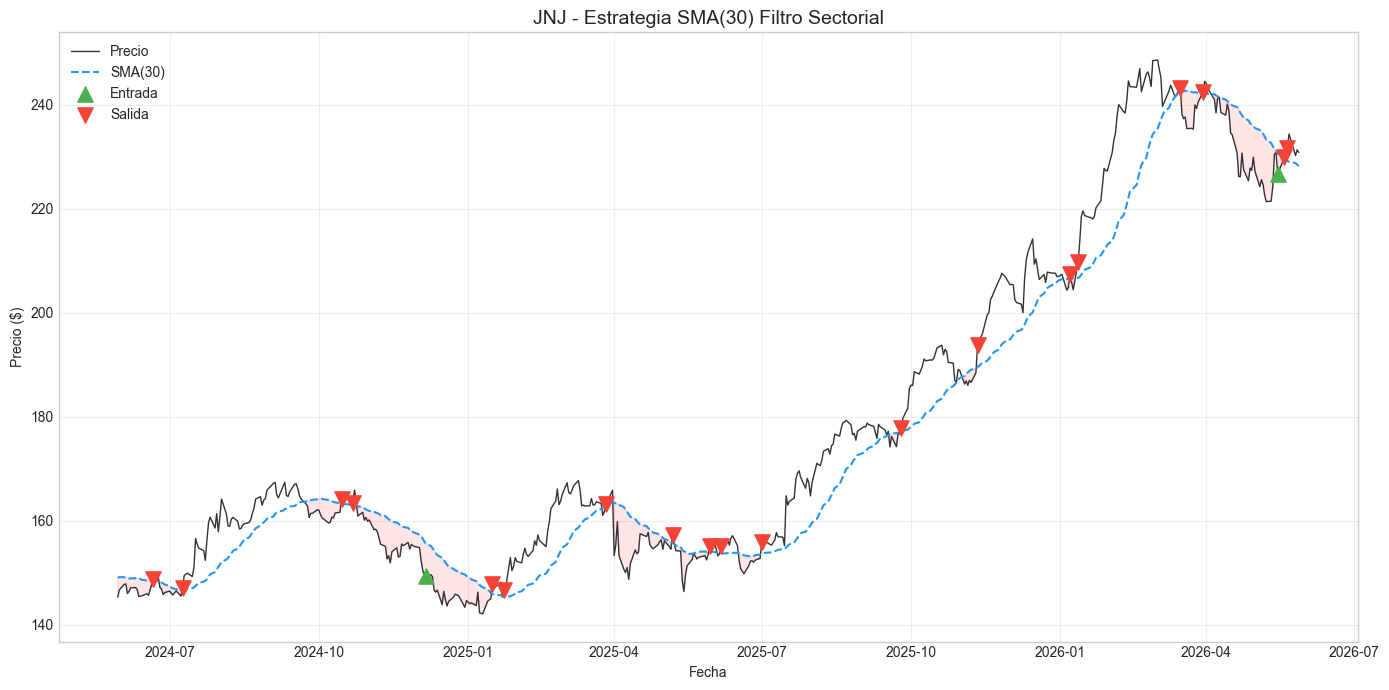

In [5]:
def plot_strategy_signals(df, ticker, last_n_days=500):
    """Visualiza precio, SMA y señales de entrada/salida."""
    data = df.tail(last_n_days)
    
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # Precio y SMA
    ax.plot(data.index, data['Close'], linewidth=1, color='#333333', label='Precio')
    ax.plot(data.index, data['SMA_30'], linewidth=1.5, color='#2196F3', 
            label=f'SMA({SMA_PERIOD})', linestyle='--')
    
    # Zona por debajo de SMA
    below = data[data['below_sma']]
    ax.fill_between(data.index, data['Close'], data['SMA_30'],
                    where=data['below_sma'], alpha=0.1, color='red')
    
    # Señales de entrada
    entries = data[data['entry_signal']]
    ax.scatter(entries.index, entries['Close'], marker='^', color='#4CAF50', 
              s=120, zorder=5, label='Entrada')
    
    # Señales de salida
    exits = data[data['exit_signal']]
    ax.scatter(exits.index, exits['Close'], marker='v', color='#F44336', 
              s=120, zorder=5, label='Salida')
    
    ax.set_title(f'{ticker} - Estrategia SMA({SMA_PERIOD}) Filtro Sectorial', fontsize=14)
    ax.set_xlabel('Fecha')
    ax.set_ylabel('Precio ($)')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_strategy_signals(jnj, 'JNJ')

## 6. Aplicar a todo el universo

JNJ: 7 señales de entrada detectadas
PFE: 6 señales de entrada detectadas
UNH: 4 señales de entrada detectadas
ABBV: 5 señales de entrada detectadas
MRK: 2 señales de entrada detectadas

Visualizando JNJ (más señales):


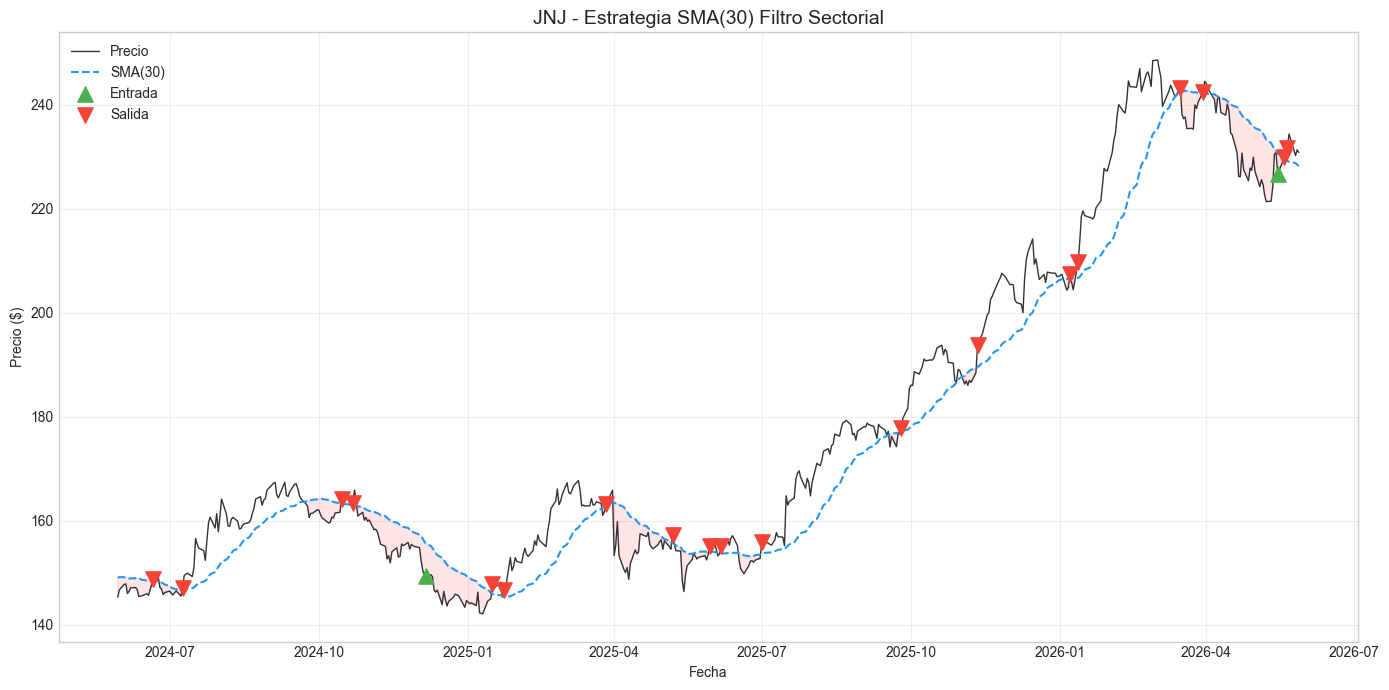

In [6]:
# Detectar señales para todos los tickers
resultados = {}
for ticker in TICKERS_SALUD:
    if ticker in datos:
        datos[ticker]['SMA_30'] = sma(datos[ticker], length=SMA_PERIOD)
        resultados[ticker] = detect_signals(datos[ticker])
        entries = resultados[ticker]['entry_signal'].sum()
        print(f"{ticker}: {entries} señales de entrada detectadas")

# Visualizar el que más señales tenga
best_ticker = max(resultados, key=lambda t: resultados[t]['entry_signal'].sum())
print(f"\nVisualizando {best_ticker} (más señales):")
plot_strategy_signals(resultados[best_ticker], best_ticker)

## Resumen

En este notebook hemos:

1. ✅ Descargado datos del sector salud vía OpenBB
2. ✅ Calculado SMA(30) para todo el universo
3. ✅ Implementado la lógica de detección de señales (entrada: 30 días bajo SMA)
4. ✅ Visualizado señales sobre gráficos de precio

---

**Siguiente paso**: Abre `01_backtesting.ipynb` para evaluar la estrategia con métricas formales.